In [1]:
import os

# Change this variable if the root folder name has been changed
root_dir = "nvae-shape-encoding"
current_dir = os.getcwd()

if not current_dir.endswith(root_dir):
    %cd ../..

assert os.getcwd().endswith(root_dir)

/Users/freddy/Desktop/Unshared/nvae-shape-encoding


/Users/freddy/Desktop/Unshared/nvae-shape-encoding/venv/lib/python3.11/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import lightning as L
import torch

from arch.nvae.nvae import NVAE
from const import SEED
from data_modules.acdc import ACDCMaskDataModule
from utils.utils import setup_device

model_path = "logs/nvae_acdc/default/pc-4-ws-6420-b-10/checkpoints/epoch=97-step=20972.ckpt"

# Setup device
device = setup_device()
print(f"Device: {device}")

# Seed
L.seed_everything(SEED)

# Load data
data_module = ACDCMaskDataModule(batch_size=20)

# Reseed after preprocessing data
L.seed_everything(SEED)

# Load model
model = NVAE.load_from_checkpoint(model_path)

/Users/freddy/Desktop/Unshared/nvae-shape-encoding/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Seed set to 1969


Device: mps
Preprocessed training data found. Loading...
Preprocessed test data found. Loading...


Seed set to 1969


In [3]:
from utils.utils import get_data

loader_test = data_module.test_dataloader()
data_test = get_data(loader_test)
data_test.shape

torch.Size([1076, 4, 128, 128])

Pick 2 masks, then perform linear interpolation.

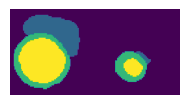

In [4]:
from utils.utils import show_samples

x1 = data_test[1].unsqueeze(0)
x2 = data_test[19].unsqueeze(0)

# Show masks
x = torch.cat([x1, x2], dim=0)
samples = torch.argmax(x, dim=1).unsqueeze(1)
show_samples(samples, rgb=False, ncol=2, figsize=(2, 4))

In [5]:
with torch.no_grad():
    model.eval()
    model.to(device)
    x1 = x1.to(device)
    x2 = x2.to(device)

    zs1 = model.get_latent(x1, test=True)
    zs2 = model.get_latent(x2, test=True)

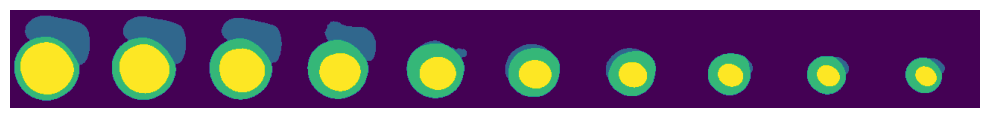

In [17]:
from arch.nvae.decoder import DecoderCombinerCell

def lerp_between_latents(
    model: NVAE,
    zs1: list[torch.Tensor],
    zs2: list[torch.Tensor],
    num_interpolations: int = 10,
):
    """
    Linearly interpolate between the latent representations of two samples,
    then visualise the reconstructions.
    """
    zs = []
    
    for z1, z2 in zip(zs1, zs2):
        z_buffer = []
        
        for i in range(num_interpolations):
            z = torch.lerp(z1, z2, i / (num_interpolations - 1))
            z_buffer.append(z)
        
        z_buffer = torch.stack(z_buffer).squeeze(1)
        zs.append(z_buffer)
    
    idx_dec = 0
    
    z = zs[idx_dec]
    
    # [1, top_channels, width, height]
    x = model.decoder.top_prior.unsqueeze(0)
    # [num_samples, top_channels, width, height]
    x = x.expand(num_interpolations, -1, -1, -1)
    
    for cell in model.decoder.tower:
        if isinstance(cell, DecoderCombinerCell):
            if idx_dec > 0:
                z = zs[idx_dec]

            x = cell(x, z)
            
            idx_dec += 1
        else:
            x = cell(x)
    
    x_hat_logits = model.decoder.postprocess(x)
    feats_hat_logits = model.conditional_coder(x_hat_logits)
    
    return feats_hat_logits

num_interpolations = 10

samples = lerp_between_latents(model, zs1, zs2, num_interpolations)
samples = torch.argmax(samples, dim=1).unsqueeze(1)
show_samples(samples, rgb=False, ncol=num_interpolations, figsize=(num_interpolations, 4))